# 🔧 Módulo 2: Pré-processamento de Dados

## Objetivos de Aprendizagem
- Entender os tipos de dados e variáveis em ML
- Aplicar técnicas de tratamento de valores ausentes
- Detectar e tratar outliers com IQR e Z-score
- Normalizar e padronizar features
- Calcular WOE e Information Value para variáveis categóricas
- Visualizar e explorar dados com gráficos informativos

## 1. Por que Pré-processar Dados?

Dados reais são **sujos**, **incompletos** e **inconsistentes**. Em projetos reais de Machine Learning, raramente recebemos um dataset pronto para uso. Os problemas mais comuns incluem:

- **Valores ausentes (NaN)**: sensores com falha, campos não preenchidos, registros corrompidos
- **Outliers**: erros de digitação, casos extremos legítimos ou fraudes
- **Escalas diferentes**: idade (0–100) vs. renda (0–500.000) prejudicam algoritmos baseados em distância
- **Variáveis categóricas**: algoritmos de ML trabalham com números, não texto
- **Distribuições assimétricas**: renda, valor de transações, tempo de resposta

> **"80% do tempo em ML é gasto em preparação de dados"** — frase famosa entre cientistas de dados, que reflete a realidade dos projetos de campo.

### Etapas do Pipeline de Pré-processamento

```
Dados Brutos
    │
    ▼
1. Exploração e Diagnóstico (EDA)
    │
    ▼
2. Tratamento de Valores Ausentes
    │
    ▼
3. Detecção e Tratamento de Outliers
    │
    ▼
4. Encoding de Variáveis Categóricas
    │
    ▼
5. Normalização / Padronização
    │
    ▼
Dados Prontos para Modelagem
```

## 2. Teoria e Equações

### 2.1 Normalização Min-Max
$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$
Resultado: valores entre [0, 1]

### 2.2 Padronização Z-score
$$X_{std} = \frac{X - \mu}{\sigma}$$
Resultado: média=0, desvio padrão=1

### 2.3 Detecção de Outliers — Z-score
$$z = \frac{x - \mu}{\sigma}, \quad |z| > 3 \Rightarrow \text{outlier}$$

### 2.4 Regra do IQR (Interquartile Range)
$$IQR = Q3 - Q1$$
$$\text{Outlier se: } x < Q1 - 1.5 \cdot IQR \text{ ou } x > Q3 + 1.5 \cdot IQR$$

### 2.5 Weight of Evidence (WOE)
$$WOE_i = \ln\left(\frac{\text{Dist. de Bons}_i}{\text{Dist. de Maus}_i}\right) = \ln\left(\frac{n_{bons,i}/N_{bons}}{n_{maus,i}/N_{maus}}\right)$$

### 2.6 Information Value (IV)
$$IV = \sum_{i=1}^{n} (DB_i - DM_i) \times WOE_i$$

**Interpretação do IV:**

| IV | Poder Preditivo |
|----|----------------|
| < 0.02 | Inútil |
| 0.02 – 0.1 | Fraco |
| 0.1 – 0.3 | Médio |
| 0.3 – 0.5 | Forte |
| > 0.5 | Suspeito (possível data leak) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Dataset sintético: solicitações de crédito bancário
n = 500

df = pd.DataFrame({
    'idade': np.clip(np.random.normal(38, 12, n).astype(int), 18, 80),
    'renda_mensal': np.random.lognormal(8.5, 0.6, n),  # distribuição assimétrica
    'divida_total': np.random.lognormal(7.0, 1.2, n),
    'score_anterior': np.random.normal(620, 95, n).clip(300, 850).astype(int),
    'num_dependentes': np.random.poisson(1.5, n).clip(0, 6),
    'escolaridade': np.random.choice(['Fundamental', 'Médio', 'Superior', 'Pós-graduação'],
                                      n, p=[0.15, 0.40, 0.35, 0.10]),
    'estado_civil': np.random.choice(['Solteiro', 'Casado', 'Divorciado'], n, p=[0.35, 0.50, 0.15]),
    'inadimplente': np.random.binomial(1, 0.25, n)  # target: 25% inadimplência
})

# Introduzir valores ausentes (simulando dados reais)
for col, pct in [('renda_mensal', 0.08), ('score_anterior', 0.12), ('escolaridade', 0.05)]:
    idx = np.random.choice(n, int(n * pct), replace=False)
    df.loc[idx, col] = np.nan

# Introduzir outliers extremos
df.loc[np.random.choice(n, 5), 'renda_mensal'] = np.random.uniform(80000, 150000, 5)
df.loc[np.random.choice(n, 3), 'divida_total'] = np.random.uniform(500000, 1000000, 3)

print("=" * 55)
print("📊 DATASET: Solicitações de Crédito Bancário")
print("=" * 55)
print(f"\nDimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"\nVariáveis numéricas: {list(df.select_dtypes(include=[np.number]).columns)}")
print(f"Variáveis categóricas: {list(df.select_dtypes(include=['object']).columns)}")
print(f"\nTaxa de inadimplência: {df['inadimplente'].mean():.1%}")
print("\n📋 Primeiras 5 linhas:")
display(df.head())
print("\n📊 Estatísticas descritivas:")
display(df.describe().round(2))
print("\n❓ Valores ausentes:")
missing = df.isnull().sum()
display(pd.DataFrame({'Total': missing, 'Percentual': (missing/n*100).round(1)}).query('Total > 0'))

📊 DATASET: Solicitações de Crédito Bancário

Dimensões: 500 linhas × 8 colunas

Variáveis numéricas: ['idade', 'renda_mensal', 'divida_total', 'score_anterior', 'num_dependentes', 'inadimplente']
Variáveis categóricas: ['escolaridade', 'estado_civil']

Taxa de inadimplência: 24.8%

📋 Primeiras 5 linhas:


,idade,renda_mensal,divida_total,score_anterior,num_dependentes,escolaridade,estado_civil,inadimplente
0,43,8567.288169,5879.497182,693.0,1,Fundamental,Solteiro,1
1,36,15454.414726,3326.115613,567.0,1,Superior,Casado,0
2,45,2123.581769,1177.980068,542.0,2,Superior,Divorciado,0
3,56,6889.691183,504.554503,NaN,2,Fundamental,Casado,0
4,35,3326.295358,2534.794826,603.0,0,Superior,Solteiro,0



📊 Estatísticas descritivas:


,idade,renda_mensal,divida_total,score_anterior,num_dependentes,inadimplente
count,500.00,461.00,500.00,440.00,500.00,500.00
mean,37.76,6922.28,8005.74,623.02,1.48,0.25
std,11.36,10363.99,70758.56,93.58,1.26,0.43
min,18.00,974.44,33.94,340.00,0.00,0.00
25%,29.00,3477.04,532.24,562.00,1.00,0.00
50%,38.00,5053.63,1268.26,617.50,1.00,0.00
75%,45.00,7397.52,2737.42,688.50,2.00,0.00
max,80.00,112249.85,934101.54,850.00,6.00,1.00



❓ Valores ausentes:


,Total,Percentual
renda_mensal,39,7.8
score_anterior,60,12.0
escolaridade,25,5.0


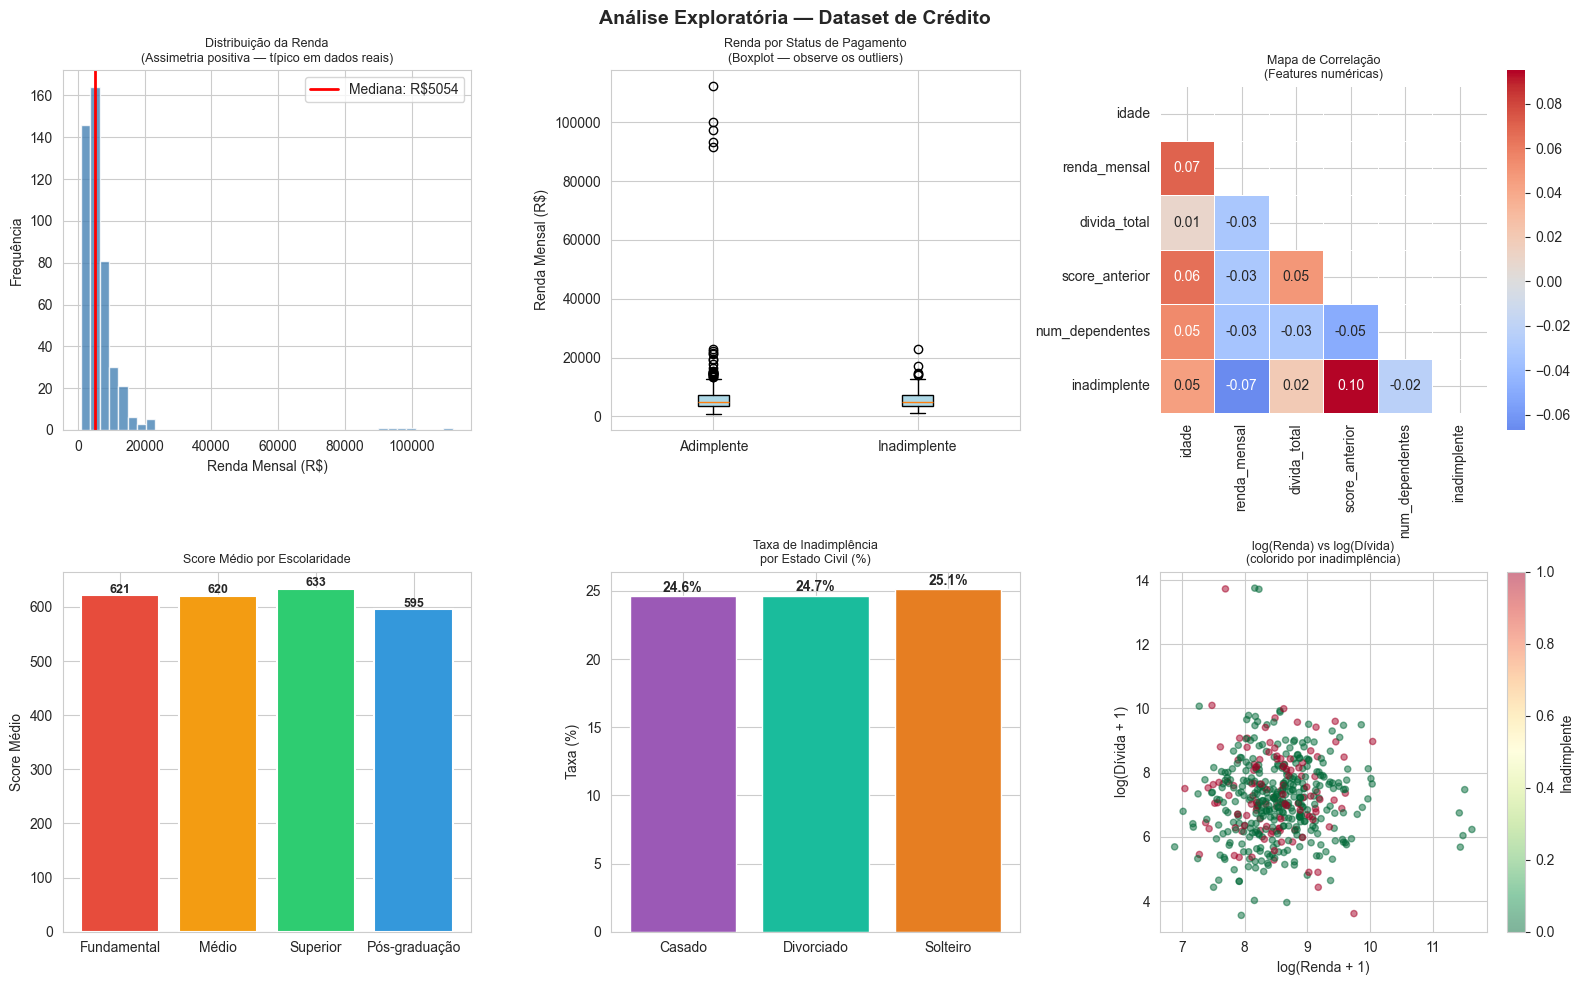

✅ Gráfico salvo em ../imagens/02_exploracao_inicial.png


In [2]:
import os
os.makedirs('../imagens', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Análise Exploratória — Dataset de Crédito', fontsize=14, fontweight='bold')

# 1. Distribuição da renda (assimétrica)
axes[0,0].hist(df['renda_mensal'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Distribuição da Renda\n(Assimetria positiva — típico em dados reais)', fontsize=9)
axes[0,0].set_xlabel('Renda Mensal (R$)')
axes[0,0].set_ylabel('Frequência')
axes[0,0].axvline(df['renda_mensal'].median(), color='red', lw=2, label=f"Mediana: R${df['renda_mensal'].median():.0f}")
axes[0,0].legend()

# 2. Boxplot com outliers
bp_data = [df[df['inadimplente']==0]['renda_mensal'].dropna(),
           df[df['inadimplente']==1]['renda_mensal'].dropna()]
axes[0,1].boxplot(bp_data, labels=['Adimplente', 'Inadimplente'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
axes[0,1].set_title('Renda por Status de Pagamento\n(Boxplot — observe os outliers)', fontsize=9)
axes[0,1].set_ylabel('Renda Mensal (R$)')

# 3. Correlação
corr_df = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0,2], center=0, square=True, linewidths=0.5)
axes[0,2].set_title('Mapa de Correlação\n(Features numéricas)', fontsize=9)

# 4. Score por escolaridade
order_esc = ['Fundamental', 'Médio', 'Superior', 'Pós-graduação']
df_esc = df.dropna(subset=['escolaridade'])
medias = [df_esc[df_esc['escolaridade']==e]['score_anterior'].mean() for e in order_esc]
bars = axes[1,0].bar(order_esc, medias, color=['#e74c3c','#f39c12','#2ecc71','#3498db'],
                      edgecolor='white', linewidth=1.5)
axes[1,0].set_title('Score Médio por Escolaridade', fontsize=9)
axes[1,0].set_ylabel('Score Médio')
for bar, v in zip(bars, medias):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+5,
                    f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')

# 5. Taxa de inadimplência por estado civil
taxa_inadimp = df.groupby('estado_civil')['inadimplente'].mean() * 100
axes[1,1].bar(taxa_inadimp.index, taxa_inadimp.values,
               color=['#9b59b6','#1abc9c','#e67e22'], edgecolor='white')
axes[1,1].set_title('Taxa de Inadimplência\npor Estado Civil (%)', fontsize=9)
axes[1,1].set_ylabel('Taxa (%)')
for i, (idx, v) in enumerate(taxa_inadimp.items()):
    axes[1,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 6. Scatter: Renda vs Dívida
sc = axes[1,2].scatter(np.log1p(df['renda_mensal']), np.log1p(df['divida_total']),
                        c=df['inadimplente'], cmap='RdYlGn_r', alpha=0.5, s=20)
plt.colorbar(sc, ax=axes[1,2], label='Inadimplente')
axes[1,2].set_title('log(Renda) vs log(Dívida)\n(colorido por inadimplência)', fontsize=9)
axes[1,2].set_xlabel('log(Renda + 1)')
axes[1,2].set_ylabel('log(Dívida + 1)')

plt.tight_layout()
plt.savefig('../imagens/02_exploracao_inicial.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em ../imagens/02_exploracao_inicial.png")

🔧 TRATAMENTO DE VALORES AUSENTES
✅ renda_mensal: imputada com mediana (R$ 5054)
✅ score_anterior: imputado com KNN (k=5 vizinhos mais similares)
✅ escolaridade: imputada com moda ('Médio')

📊 Valores ausentes após imputação: 0


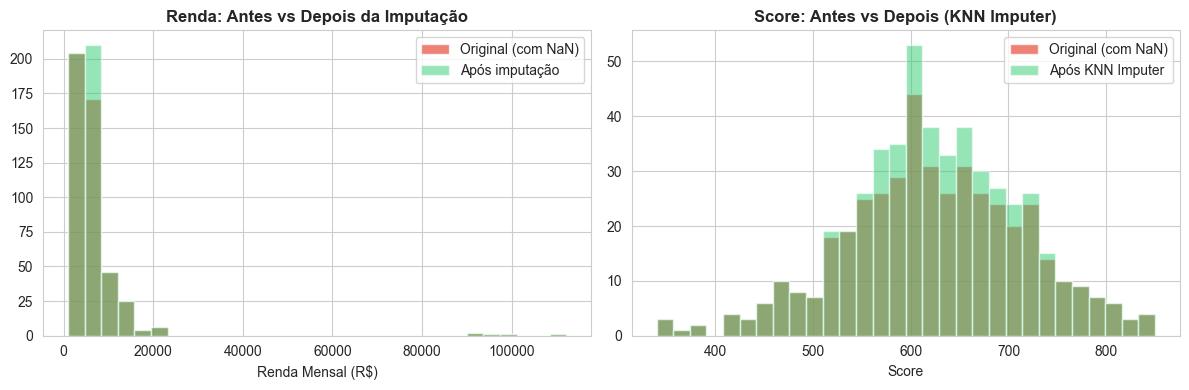

✅ Gráfico salvo em ../imagens/02_imputacao.png


In [3]:
from sklearn.impute import SimpleImputer, KNNImputer

print("=" * 55)
print("🔧 TRATAMENTO DE VALORES AUSENTES")
print("=" * 55)

df_clean = df.copy()

# Estratégia 1: Mediana para variáveis numéricas assimétricas
imp_mediana = SimpleImputer(strategy='median')
df_clean['renda_mensal'] = imp_mediana.fit_transform(df[['renda_mensal']])
print(f"✅ renda_mensal: imputada com mediana (R$ {df['renda_mensal'].median():.0f})")

# Estratégia 2: KNN Imputer para score (usa correlação com outras features)
imp_knn = KNNImputer(n_neighbors=5)
cols_num = ['idade', 'renda_mensal', 'divida_total', 'score_anterior', 'num_dependentes']
df_clean[cols_num] = imp_knn.fit_transform(df_clean[cols_num])
print(f"✅ score_anterior: imputado com KNN (k=5 vizinhos mais similares)")

# Estratégia 3: Moda para categóricas
moda_esc = df['escolaridade'].mode()[0]
df_clean['escolaridade'] = df['escolaridade'].fillna(moda_esc)
print(f"✅ escolaridade: imputada com moda ('{moda_esc}')")

print(f"\n📊 Valores ausentes após imputação: {df_clean.isnull().sum().sum()}")

# Comparar distribuições antes e depois
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['renda_mensal'].dropna(), bins=30, alpha=0.7, color='#e74c3c', label='Original (com NaN)')
axes[0].hist(df_clean['renda_mensal'], bins=30, alpha=0.5, color='#2ecc71', label='Após imputação')
axes[0].set_title('Renda: Antes vs Depois da Imputação', fontweight='bold')
axes[0].set_xlabel('Renda Mensal (R$)')
axes[0].legend()

axes[1].hist(df['score_anterior'].dropna(), bins=30, alpha=0.7, color='#e74c3c', label='Original (com NaN)')
axes[1].hist(df_clean['score_anterior'], bins=30, alpha=0.5, color='#2ecc71', label='Após KNN Imputer')
axes[1].set_title('Score: Antes vs Depois (KNN Imputer)', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../imagens/02_imputacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em ../imagens/02_imputacao.png")

🎯 DETECÇÃO E TRATAMENTO DE OUTLIERS

📐 Método IQR:
  renda_mensal: 34 outliers (6.8%)
    Limites: [-1920.47, 12658.15]
  divida_total: 52 outliers (10.4%)
    Limites: [-2775.54, 6045.19]

📐 Método Z-score:
  renda_mensal: 5 outliers Z-score (|z|>3)
  divida_total: 3 outliers Z-score (|z|>3)

✅ renda_mensal: Winsorized [1408, 23705]

✅ divida_total: Winsorized [82, 23626]


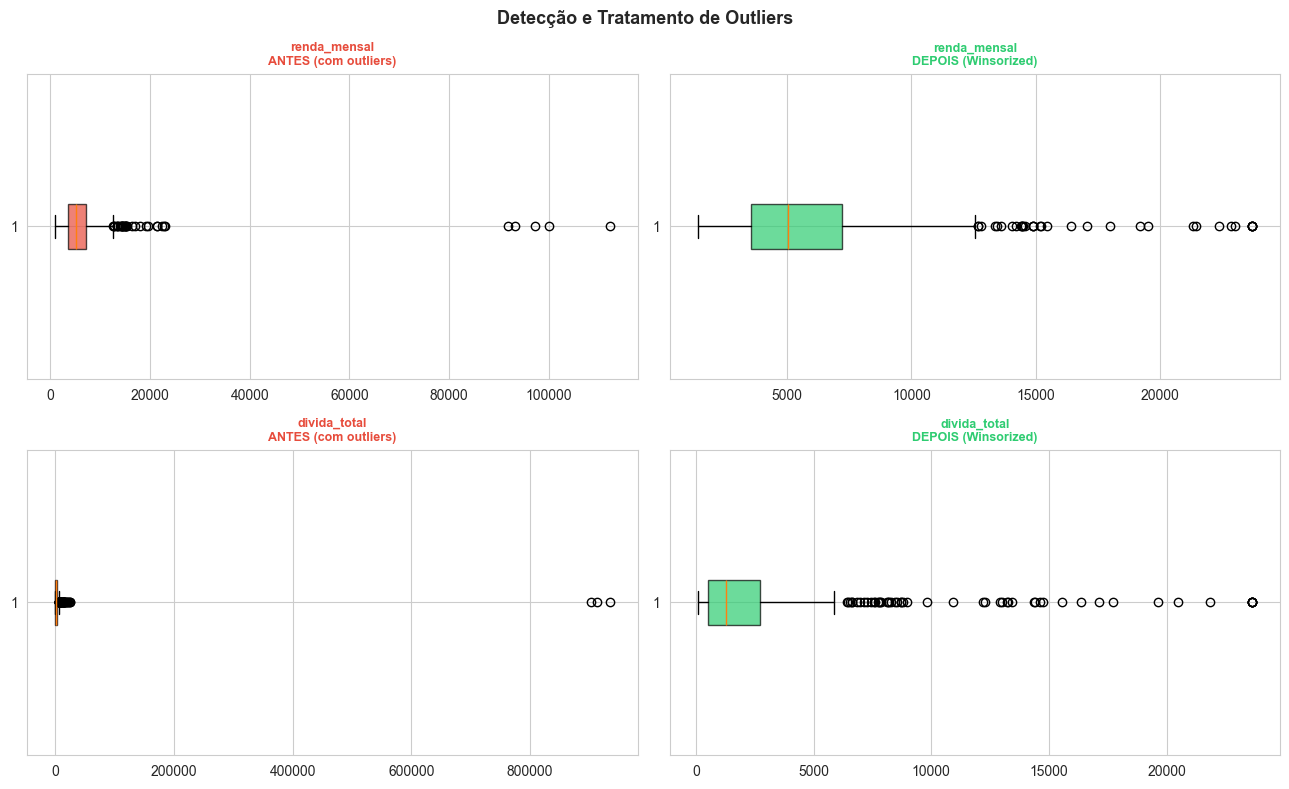

✅ Gráfico salvo em ../imagens/02_outliers.png


In [4]:
print("=" * 55)
print("🎯 DETECÇÃO E TRATAMENTO DE OUTLIERS")
print("=" * 55)

def detectar_outliers_iqr(serie, nome):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = serie[(serie < limite_inf) | (serie > limite_sup)]
    print(f"  {nome}: {len(outliers)} outliers ({len(outliers)/len(serie)*100:.1f}%)")
    print(f"    Limites: [{limite_inf:.2f}, {limite_sup:.2f}]")
    return limite_inf, limite_sup

def detectar_outliers_zscore(serie, nome, threshold=3):
    z = np.abs(stats.zscore(serie.dropna()))
    n_outliers = (z > threshold).sum()
    print(f"  {nome}: {n_outliers} outliers Z-score (|z|>{threshold})")
    return n_outliers

print("\n📐 Método IQR:")
lim_inf_renda, lim_sup_renda = detectar_outliers_iqr(df_clean['renda_mensal'], 'renda_mensal')
detectar_outliers_iqr(df_clean['divida_total'], 'divida_total')

print("\n📐 Método Z-score:")
detectar_outliers_zscore(df_clean['renda_mensal'], 'renda_mensal')
detectar_outliers_zscore(df_clean['divida_total'], 'divida_total')

# Tratamento: Winsorization (capping nos percentis 1% e 99%)
df_sem_outliers = df_clean.copy()
for col in ['renda_mensal', 'divida_total']:
    p01, p99 = df_clean[col].quantile([0.01, 0.99])
    df_sem_outliers[col] = df_clean[col].clip(p01, p99)
    print(f"\n✅ {col}: Winsorized [{p01:.0f}, {p99:.0f}]")

# Visualização comparativa
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Detecção e Tratamento de Outliers', fontsize=13, fontweight='bold')

for i, (col, ax_orig, ax_clean) in enumerate(zip(['renda_mensal', 'divida_total'],
                                                   [axes[0,0], axes[1,0]],
                                                   [axes[0,1], axes[1,1]])):
    ax_orig.boxplot(df_clean[col], vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#e74c3c', alpha=0.7))
    ax_orig.set_title(f'{col}\nANTES (com outliers)', fontsize=9, color='#e74c3c', fontweight='bold')

    ax_clean.boxplot(df_sem_outliers[col], vert=False, patch_artist=True,
                     boxprops=dict(facecolor='#2ecc71', alpha=0.7))
    ax_clean.set_title(f'{col}\nDEPOIS (Winsorized)', fontsize=9, color='#2ecc71', fontweight='bold')

plt.tight_layout()
plt.savefig('../imagens/02_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em ../imagens/02_outliers.png")

📏 NORMALIZAÇÃO, PADRONIZAÇÃO E ENCODING


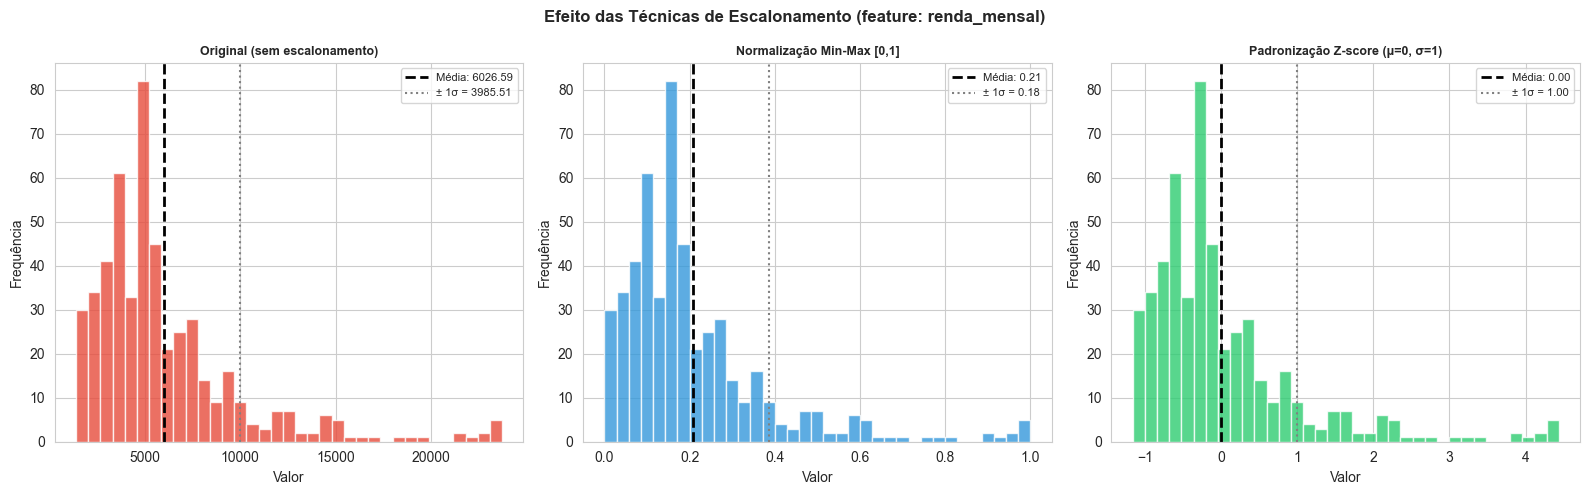


🏷️ Label Encoding (variáveis ordinais):
  Escolaridade: {'Fundamental': 0, 'Médio': 1, 'Superior': 2, 'Pós-graduação': 3}

🎯 One-Hot Encoding (variáveis nominais):
  Estado Civil → ['civil_Casado', 'civil_Divorciado', 'civil_Solteiro']

  Shape antes: (500, 9) → Shape depois: (500, 11)

✅ Gráfico salvo em ../imagens/02_escalonamento.png


In [5]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder

print("=" * 55)
print("📏 NORMALIZAÇÃO, PADRONIZAÇÃO E ENCODING")
print("=" * 55)

cols_num = ['idade', 'renda_mensal', 'divida_total', 'score_anterior', 'num_dependentes']

# Escalonadores
scaler_mm = MinMaxScaler()
scaler_ss = StandardScaler()

X_orig = df_sem_outliers[cols_num].values
X_minmax = scaler_mm.fit_transform(X_orig)
X_zscore = scaler_ss.fit_transform(X_orig)

# Comparação visual
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Efeito das Técnicas de Escalonamento (feature: renda_mensal)',
             fontsize=12, fontweight='bold')

titles = ['Original (sem escalonamento)', 'Normalização Min-Max [0,1]', 'Padronização Z-score (μ=0, σ=1)']
data_list = [X_orig[:,1], X_minmax[:,1], X_zscore[:,1]]
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, title, data, color in zip(axes, titles, data_list, colors):
    ax.hist(data, bins=35, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
    ax.axvline(np.mean(data), color='black', lw=2, linestyle='--',
                label=f'Média: {np.mean(data):.2f}')
    ax.axvline(np.mean(data)+np.std(data), color='gray', lw=1.5, linestyle=':',
                label=f'± 1σ = {np.std(data):.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../imagens/02_escalonamento.png', dpi=150, bbox_inches='tight')
plt.show()

# Label Encoding
print("\n🏷️ Label Encoding (variáveis ordinais):")
le = LabelEncoder()
ordem_esc = {'Fundamental': 0, 'Médio': 1, 'Superior': 2, 'Pós-graduação': 3}
df_sem_outliers['escolaridade_cod'] = df_sem_outliers['escolaridade'].map(ordem_esc)
print(f"  Escolaridade: {ordem_esc}")

# One-Hot Encoding
print("\n🎯 One-Hot Encoding (variáveis nominais):")
df_ohe = pd.get_dummies(df_sem_outliers, columns=['estado_civil'], prefix='civil', drop_first=False)
cols_ohe = [c for c in df_ohe.columns if c.startswith('civil_')]
print(f"  Estado Civil → {cols_ohe}")
print(f"\n  Shape antes: {df_sem_outliers.shape} → Shape depois: {df_ohe.shape}")
print("\n✅ Gráfico salvo em ../imagens/02_escalonamento.png")

📊 WEIGHT OF EVIDENCE (WOE) E INFORMATION VALUE (IV)

Usados em credit scoring para medir poder preditivo de variáveis categóricas.

📊 WOE e IV para 'escolaridade':


,Categoria,N_Bons,N_Maus,WOE,IV_parcial
3,Pós-graduação,35,5,0.8366,0.0441
2,Médio,163,51,0.0526,0.0012
1,Superior,125,45,-0.0877,0.0027
0,Fundamental,53,23,-0.2745,0.0122


  → IV Total: 0.0602 (Fraco)

📊 IV para 'estado_civil': 0.0002


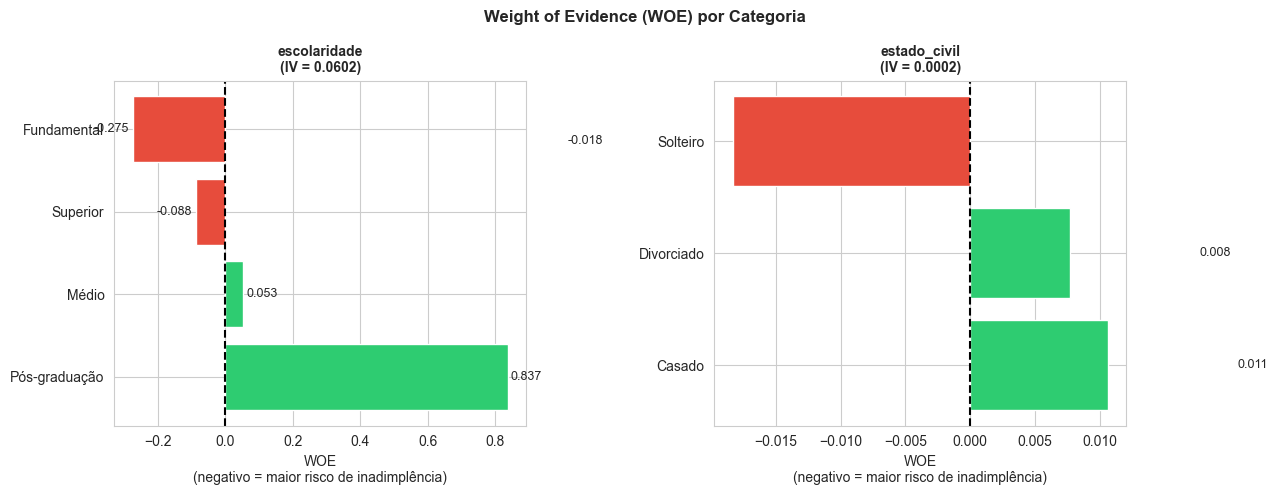

✅ Gráfico salvo em ../imagens/02_woe_iv.png


In [6]:
print("=" * 55)
print("📊 WEIGHT OF EVIDENCE (WOE) E INFORMATION VALUE (IV)")
print("=" * 55)
print("\nUsados em credit scoring para medir poder preditivo de variáveis categóricas.")

def calcular_woe_iv(df, feature, target):
    """Calcula WOE e IV para uma feature categórica."""
    total_bons = (df[target] == 0).sum()
    total_maus = (df[target] == 1).sum()

    tabela = []
    for categoria in df[feature].unique():
        mask = df[feature] == categoria
        n_bons = (df[mask][target] == 0).sum()
        n_maus = (df[mask][target] == 1).sum()

        dist_bons = n_bons / total_bons if total_bons > 0 else 0.001
        dist_maus = n_maus / total_maus if total_maus > 0 else 0.001

        # Evitar log(0)
        dist_bons = max(dist_bons, 1e-10)
        dist_maus = max(dist_maus, 1e-10)

        woe = np.log(dist_bons / dist_maus)
        iv_parcial = (dist_bons - dist_maus) * woe

        tabela.append({'Categoria': categoria, 'N_Bons': n_bons, 'N_Maus': n_maus,
                       'Dist_Bons': dist_bons, 'Dist_Maus': dist_maus,
                       'WOE': round(woe, 4), 'IV_parcial': round(iv_parcial, 4)})

    resultado = pd.DataFrame(tabela).sort_values('WOE', ascending=False)
    iv_total = resultado['IV_parcial'].sum()
    return resultado, round(iv_total, 4)

# Calcular para cada feature categórica
print("\n📊 WOE e IV para 'escolaridade':")
woe_esc, iv_esc = calcular_woe_iv(df_sem_outliers.dropna(subset=['escolaridade']),
                                    'escolaridade', 'inadimplente')
display(woe_esc[['Categoria', 'N_Bons', 'N_Maus', 'WOE', 'IV_parcial']])
print(f"  → IV Total: {iv_esc} ({'Médio' if 0.1 <= iv_esc <= 0.3 else 'Fraco' if iv_esc < 0.1 else 'Forte'})")

woe_civil, iv_civil = calcular_woe_iv(df_sem_outliers, 'estado_civil', 'inadimplente')
print(f"\n📊 IV para 'estado_civil': {iv_civil}")

# Gráfico WOE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Weight of Evidence (WOE) por Categoria', fontsize=12, fontweight='bold')

for ax, (woe_df, feature, iv) in zip(axes, [
    (woe_esc, 'escolaridade', iv_esc),
    (woe_civil, 'estado_civil', iv_civil)
]):
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in woe_df['WOE']]
    bars = ax.barh(woe_df['Categoria'], woe_df['WOE'], color=colors, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
    ax.set_title(f'{feature}\n(IV = {iv})', fontweight='bold', fontsize=10)
    ax.set_xlabel('WOE\n(negativo = maior risco de inadimplência)')
    for bar, v in zip(bars, woe_df['WOE']):
        ax.text(v + (0.01 if v >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', ha='left' if v >= 0 else 'right', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../imagens/02_woe_iv.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em ../imagens/02_woe_iv.png")

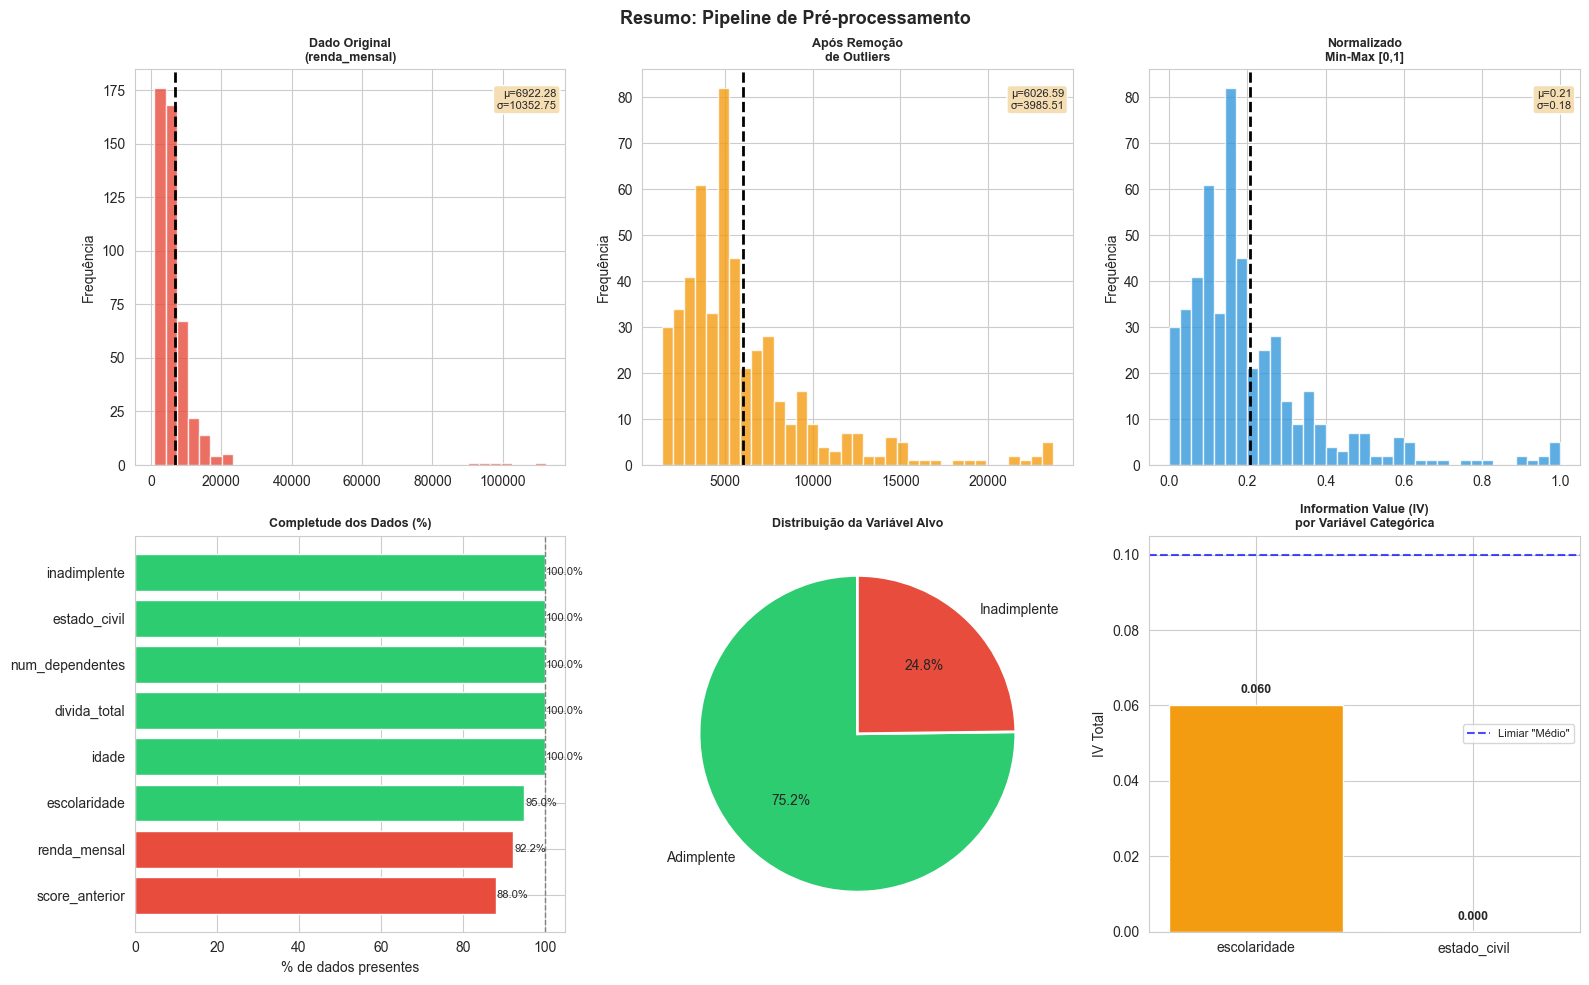

✅ Pipeline de pré-processamento concluído!
   Shape final: 500 linhas × 11 colunas
✅ Gráfico salvo em ../imagens/02_pipeline_resumo.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Resumo: Pipeline de Pré-processamento', fontsize=13, fontweight='bold')

etapas = [
    ('Dado Original\n(renda_mensal)', df['renda_mensal'].dropna(), '#e74c3c'),
    ('Após Remoção\nde Outliers', df_sem_outliers['renda_mensal'], '#f39c12'),
    ('Normalizado\nMin-Max [0,1]', MinMaxScaler().fit_transform(df_sem_outliers[['renda_mensal']]).flatten(), '#3498db'),
]

for i, (titulo, dados, cor) in enumerate(etapas):
    ax = axes[0, i]
    ax.hist(dados, bins=35, color=cor, edgecolor='white', alpha=0.8)
    ax.set_title(titulo, fontweight='bold', fontsize=9)
    ax.set_ylabel('Frequência')
    media = np.mean(dados)
    dp = np.std(dados)
    ax.axvline(media, color='black', lw=2, linestyle='--')
    ax.text(0.98, 0.95, f'μ={media:.2f}\nσ={dp:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='wheat'))

# Mapa de calor de completude
completude = ((1 - df.isnull().mean()) * 100).sort_values()
axes[1, 0].barh(completude.index, completude.values,
                color=['#e74c3c' if v < 95 else '#2ecc71' for v in completude.values])
axes[1, 0].set_title('Completude dos Dados (%)', fontweight='bold', fontsize=9)
axes[1, 0].set_xlabel('% de dados presentes')
axes[1, 0].axvline(100, color='gray', lw=1, linestyle='--')
for i, v in enumerate(completude.values):
    axes[1, 0].text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=8)

# Distribuição do target
axes[1, 1].pie([1-df['inadimplente'].mean(), df['inadimplente'].mean()],
               labels=['Adimplente', 'Inadimplente'],
               colors=['#2ecc71', '#e74c3c'],
               autopct='%1.1f%%', startangle=90,
               wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1, 1].set_title('Distribuição da Variável Alvo', fontweight='bold', fontsize=9)

# Sumário de IV
iv_resultados = {
    'escolaridade': iv_esc,
    'estado_civil': iv_civil,
}
iv_cores = ['#2ecc71' if v > 0.1 else '#f39c12' if v > 0.02 else '#e74c3c'
            for v in iv_resultados.values()]
bars = axes[1, 2].bar(iv_resultados.keys(), iv_resultados.values(), color=iv_cores, edgecolor='white')
axes[1, 2].axhline(0.1, color='blue', lw=1.5, linestyle='--', alpha=0.7, label='Limiar "Médio"')
axes[1, 2].set_title('Information Value (IV)\npor Variável Categórica', fontweight='bold', fontsize=9)
axes[1, 2].set_ylabel('IV Total')
axes[1, 2].legend(fontsize=8)
for bar, v in zip(bars, iv_resultados.values()):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.003,
                    f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../imagens/02_pipeline_resumo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pipeline de pré-processamento concluído!")
print(f"   Shape final: {df_ohe.shape[0]} linhas × {df_ohe.shape[1]} colunas")
print("✅ Gráfico salvo em ../imagens/02_pipeline_resumo.png")

## 6. Resumo e Pontos-Chave

### Técnicas de Pré-processamento Aplicadas

| Problema | Técnica | Quando Usar |
|----------|---------|------------|
| Valores ausentes (numérico) | Mediana | Dados assimétricos |
| Valores ausentes (numérico) | KNN Imputer | Quando há correlação entre features |
| Valores ausentes (categórico) | Moda | Variáveis categóricas nominais |
| Outliers extremos | Winsorization | Manter tamanho do dataset |
| Outliers | Remoção (IQR/Z-score) | Quando são erros de coleta |
| Features numéricas | Min-Max Scaling | Algoritmos sensíveis a escala (KNN, SVM) |
| Features numéricas | Z-score | Distribuições aproximadamente normais |
| Categorias ordinais | Label Encoding | Quando há ordem natural |
| Categorias nominais | One-Hot Encoding | Sem ordem natural |
| Poder preditivo | WOE + IV | Credit scoring, seleção de features |

### ⚠️ Armadilhas Comuns
1. **Data Leakage**: nunca use informação do conjunto de teste para calcular estatísticas de normalização
2. **Sempre fit no treino, transform no teste**: `scaler.fit(X_train)` → `scaler.transform(X_test)`
3. **Outliers podem ser sinais valiosos**: em fraude, o outlier É o sinal
4. **Imputação antes do split**: impute depois de separar treino/teste para evitar data leakage
5. **Escala não muda a forma da distribuição**: normalização não torna dados normais

## 7. Exercícios Propostos

### Exercício 1 — Tratamento de Ausentes (Fácil)
Crie um novo DataFrame com 10% de valores ausentes na coluna `idade`. Compare o resultado da imputação por **média** vs **mediana** quando você introduz 5 outliers na distribuição. Qual estratégia é mais robusta?

### Exercício 2 — Detecção de Outliers (Médio)
Usando o dataset de crédito, aplique os métodos IQR e Z-score na coluna `score_anterior`. Compare:
- Quantos outliers cada método detecta?
- Os mesmos registros são identificados?
- Plote ambos os resultados em boxplots lado a lado.

### Exercício 3 — Encoding Avançado (Médio)
Aplique **Target Encoding** na variável `escolaridade` (substitua cada categoria pela média de inadimplência naquela categoria). Compare o resultado com o Label Encoding manual feito neste módulo. Qual preserva melhor a ordenação por risco?

```python
# Dica: Target Encoding
target_enc = df.groupby('escolaridade')['inadimplente'].mean()
df['escolaridade_target'] = df['escolaridade'].map(target_enc)
```

### Exercício 4 — WOE em Variável Numérica (Avançado)
A função `calcular_woe_iv` foi criada para variáveis categóricas. Adapte-a para funcionar com `score_anterior` discretizado em 5 faixas (bins) usando `pd.qcut`. Calcule o IV e interprete o poder preditivo.

```python
# Dica: discretização
df['score_faixa'] = pd.qcut(df['score_anterior'], q=5, labels=['Muito Baixo','Baixo','Médio','Alto','Muito Alto'])
woe_score, iv_score = calcular_woe_iv(df.dropna(subset=['score_faixa']), 'score_faixa', 'inadimplente')
```

### Exercício 5 — Pipeline Completo (Desafio)
Construa um `sklearn.pipeline.Pipeline` completo que:
1. Separe o dataset em treino (80%) e teste (20%) com `train_test_split`
2. Aplique imputação por mediana nas variáveis numéricas
3. Aplique One-Hot Encoding em `estado_civil`
4. Normalize com `StandardScaler`
5. Treine um `LogisticRegression`
6. Avalie com `accuracy_score` e `roc_auc_score`

**Dica**: Use `ColumnTransformer` para aplicar transformações diferentes em colunas diferentes.

---
**Próximo módulo**: Módulo 3 — Regressão Linear e Logística